In [1]:
%matplotlib notebook

## Comments About PES Versions
- For HOPO PES fittings v4 and below, the coordinate rpo1 (HOP-O) is the first column, with rpo2 (HO-PO) the second column. For v6 and v7, the columns are switched.  
- Similarly, the position of the nonlinear parameters are also switched. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm
import make_pes as mpes
from scipy.optimize import minimize

In [3]:
p, orders = mpes.get_coeffs_orders('HOPO_new_fit_1.res')
nonlin_p = mpes.get_non_linear_p('HOPO_new_fit_1.res')

#pes = mpes.get_pes_v6(p, nonlin_p, orders)
pes = mpes.get_pes_v7_sin_sin(p, nonlin_p.copy(), orders)

print(nonlin_p)


[  1.60346169   1.46783211   0.96779675 110.73674459 113.09775988
   1.67613068   2.63948387   2.02179144]


[  1.60346169   1.46783211   0.96779675 110.73674459 113.09775988
   1.67613068   2.63948387   2.02179144]


<IPython.core.display.Javascript object>


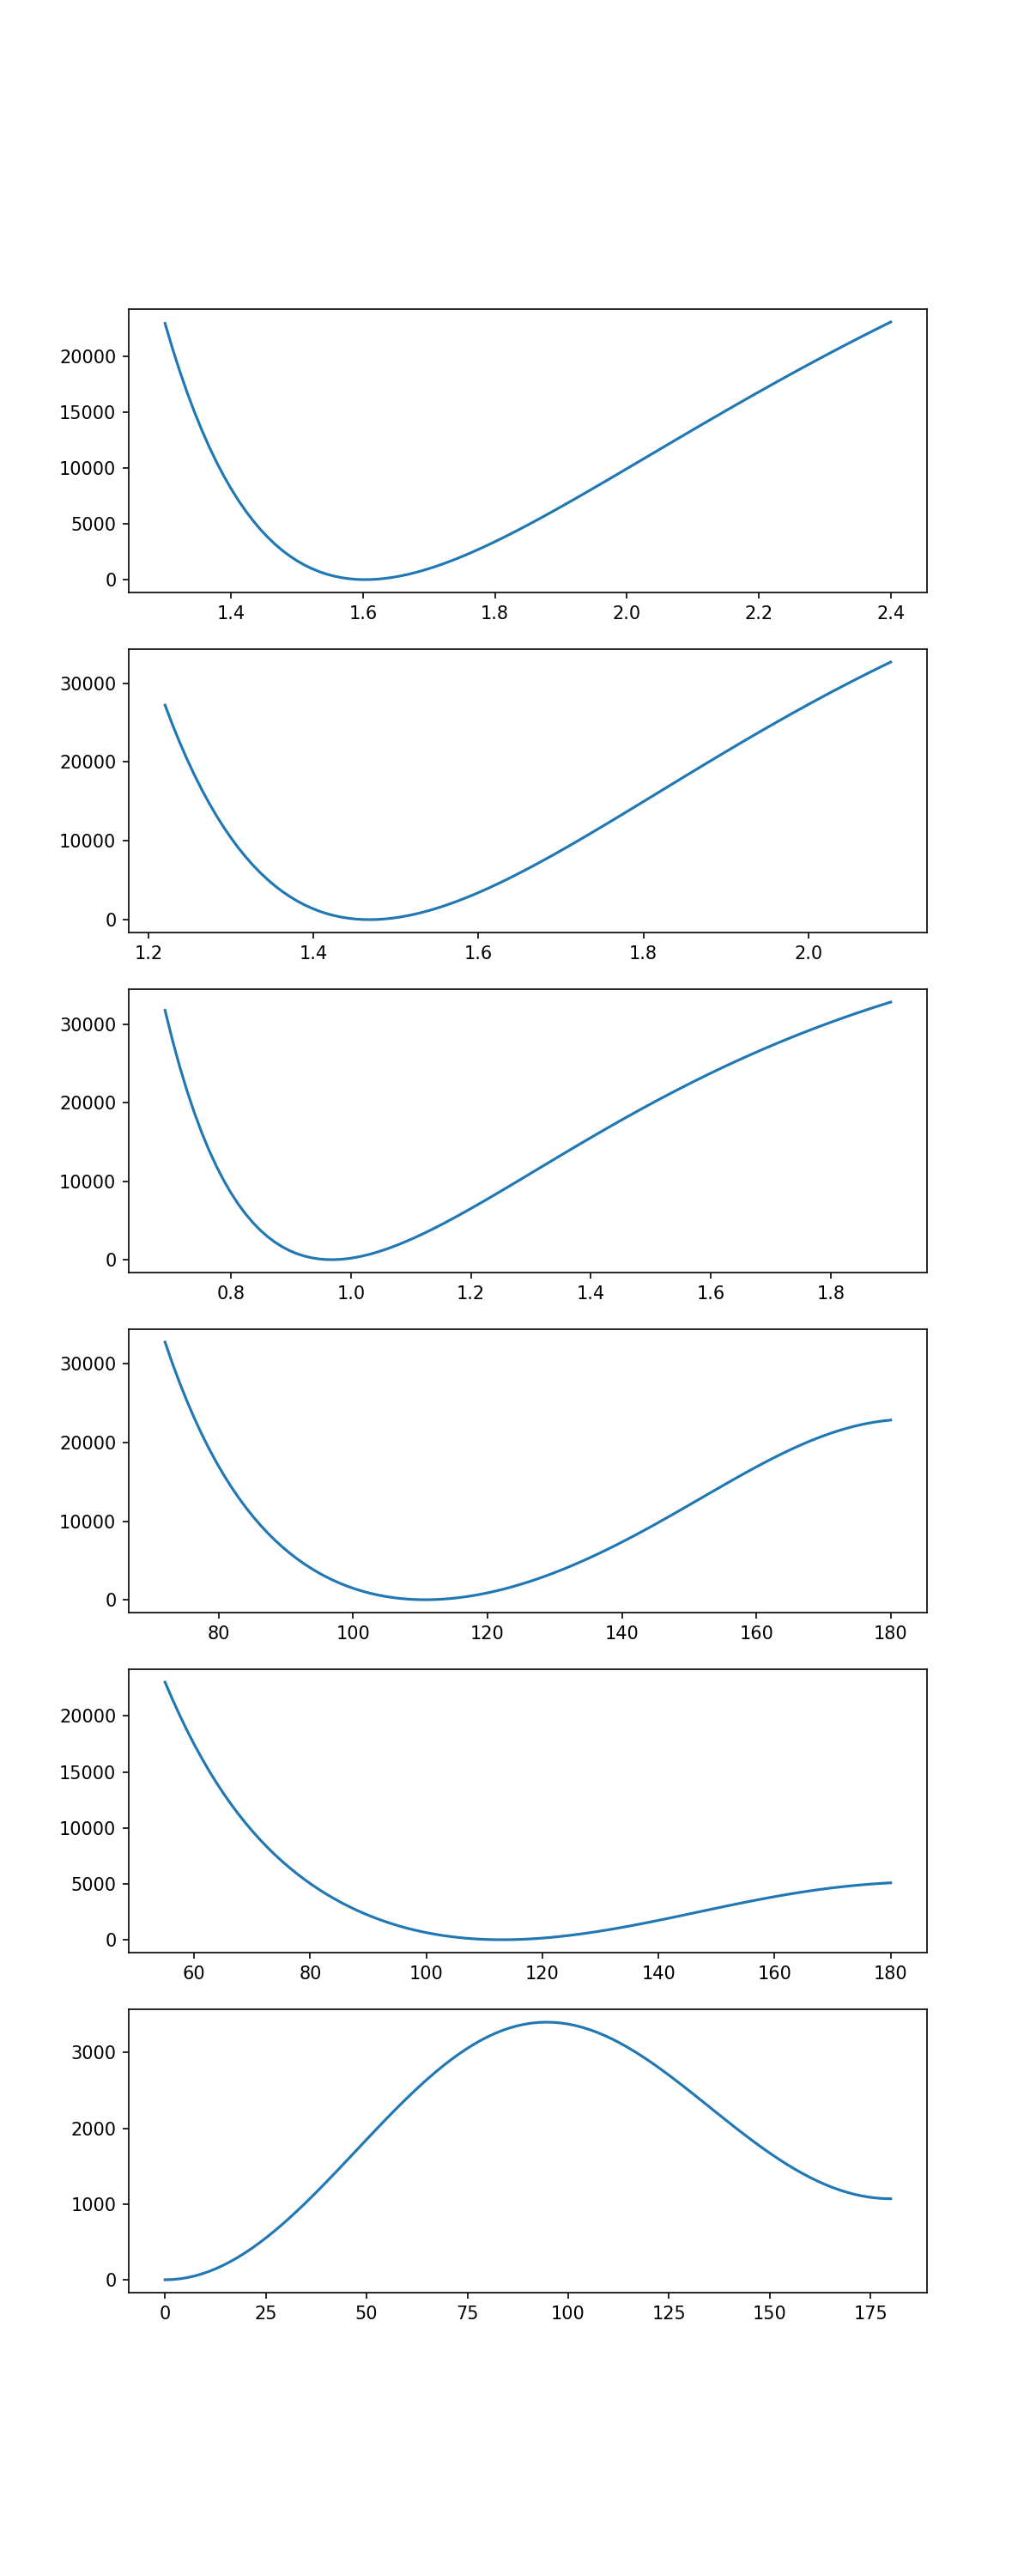

In [4]:
coordinate_lower_bounds = [1.3, 1.22, 0.69, 72, 55, 0]
coordinate_upper_bounds = [2.4, 2.10, 1.9, 180, 180, 180]
equilibriums = [1.604292, 1.468331, 0.967982, 110.7285, 113.0548, 0]
print(nonlin_p)

geometry1d = np.zeros((100, 6))

#using nonlin_p
for j in range(5):
    geometry1d[:, j] = nonlin_p[j]

fig, ax = plt.subplots(6,1, figsize=(8,20))
for i in range(6):
    geometry_1d = geometry1d.copy()
    geometry_1d[:, i] = np.linspace(coordinate_lower_bounds[i],
                                    coordinate_upper_bounds[i],
                                    100)

    ax[i].plot(geometry_1d[:, i], pes(geometry_1d))

#print(geometry1d)

In [5]:
tau_grid = np.linspace(0, 360, 40)
apoh_grid = np.linspace(75, 180, 20)
apoh_tau_mesh = np.meshgrid(apoh_grid, tau_grid)
apoh_mesh = apoh_tau_mesh[0]
tau_mesh = apoh_tau_mesh[1]

geometry_apoh_tau = np.zeros((len(apoh_grid)*len(tau_grid), 
                           6) )
geometry_apoh_tau[:, 4] = apoh_mesh.flatten()
geometry_apoh_tau[:, 5] = tau_mesh.flatten()
minima_vals = nonlin_p

for j in range(4):
    geometry_apoh_tau[:, j] = nonlin_p[j]
    
pes_vals = pes(geometry_apoh_tau)
pes_vals = np.reshape(pes_vals, 
                        (len(tau_grid), len(apoh_grid)) #shape 
                       )

<IPython.core.display.Javascript object>


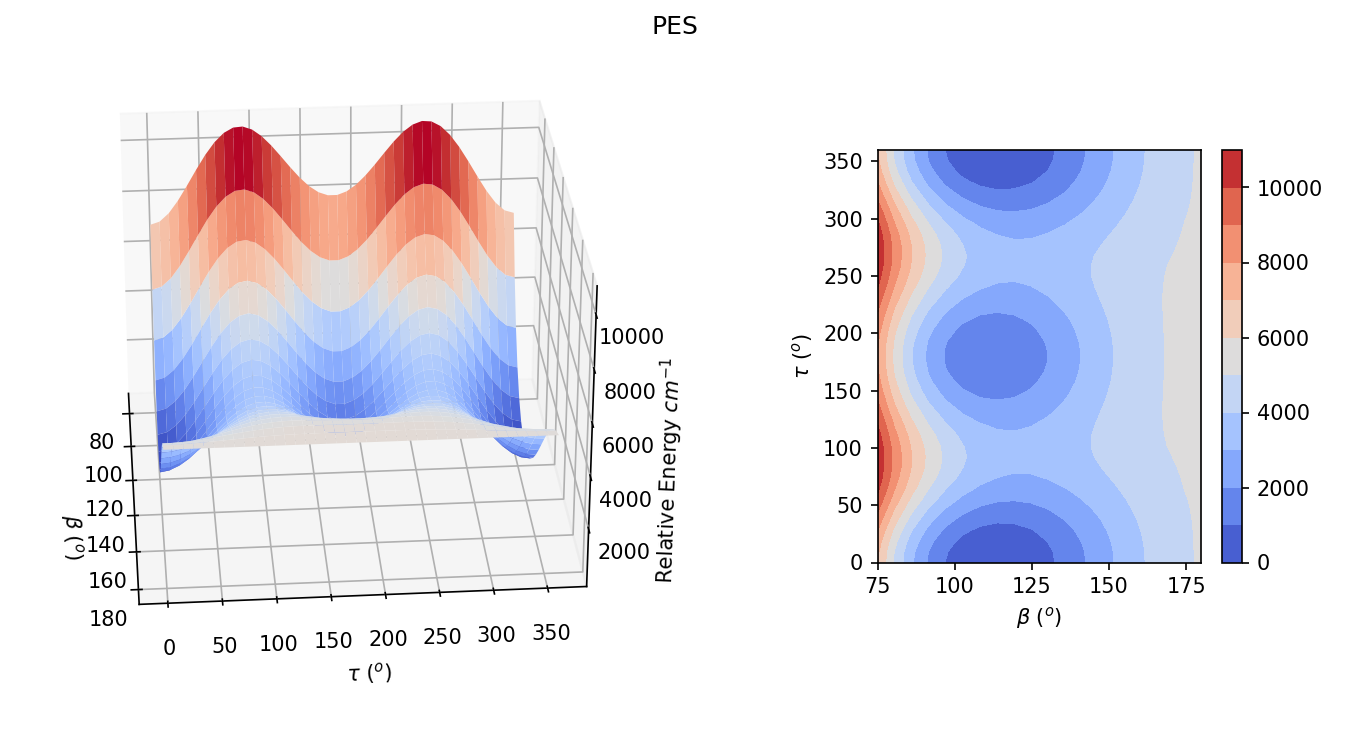

In [6]:
fig = plt.figure(figsize=(9, 5))
fig.suptitle('PES')
ax_3d = fig.add_axes([-0.1, 0.08, 0.7, 0.9], projection='3d')
#ax_3d = fig.add_subplot(1, 2, 1, projection='3d')
ax_3d.plot_surface(
    apoh_mesh, tau_mesh, pes_vals,
    cmap=cm.coolwarm,
    shade=True,           # adds lighting effect
)
#ax_3d.set_box_aspect([1,1,0.6]) 
ax_3d.set_xlabel(r'$\beta$ ($^{o}$)')
ax_3d.set_ylabel(r'$\tau$ ($^{o}$)') 
ax_3d.set_zlabel(r'Relative Energy $cm^{-1}$');
ax_3d.axis('tight');

#ax_contour = fig.add_subplot(1, 2, 2, projection=None)
ax_contour = fig.add_axes([0.65, 0.25, 0.3, 0.55])  
contour = ax_contour.contourf(
    apoh_mesh, tau_mesh, pes_vals,
    levels=10,
    cmap=cm.coolwarm
)
ax_contour.set_xlabel(r'$\beta$ ($^{o}$)')
ax_contour.set_ylabel(r'$\tau$ ($^{o}$)') 

plt.colorbar(contour, ax=ax_contour)
plt.show()

In [7]:
r1_grid = np.linspace(1.3, 2.4, 30)
r2_grid = np.linspace(1.22, 2.0, 30)
r1_r2_mesh = np.meshgrid(r1_grid, r2_grid)
r1_mesh = r1_r2_mesh[0]
r2_mesh = r1_r2_mesh[1]

geometry_r1_r2 = np.zeros((len(r1_grid)*len(r2_grid), 
                           6) )
geometry_r1_r2[:, 0] = r1_mesh.flatten()
geometry_r1_r2[:, 1] = r2_mesh.flatten()

for j in range(2,6):
    geometry_r1_r2[:, j] = nonlin_p[j]

pes_vals_r1_r2 = pes(geometry_r1_r2)
pes_vals_r1_r2 = np.reshape(pes_vals_r1_r2, 
                        (len(r1_grid), len(r2_grid)) #shape 
                       )

<IPython.core.display.Javascript object>


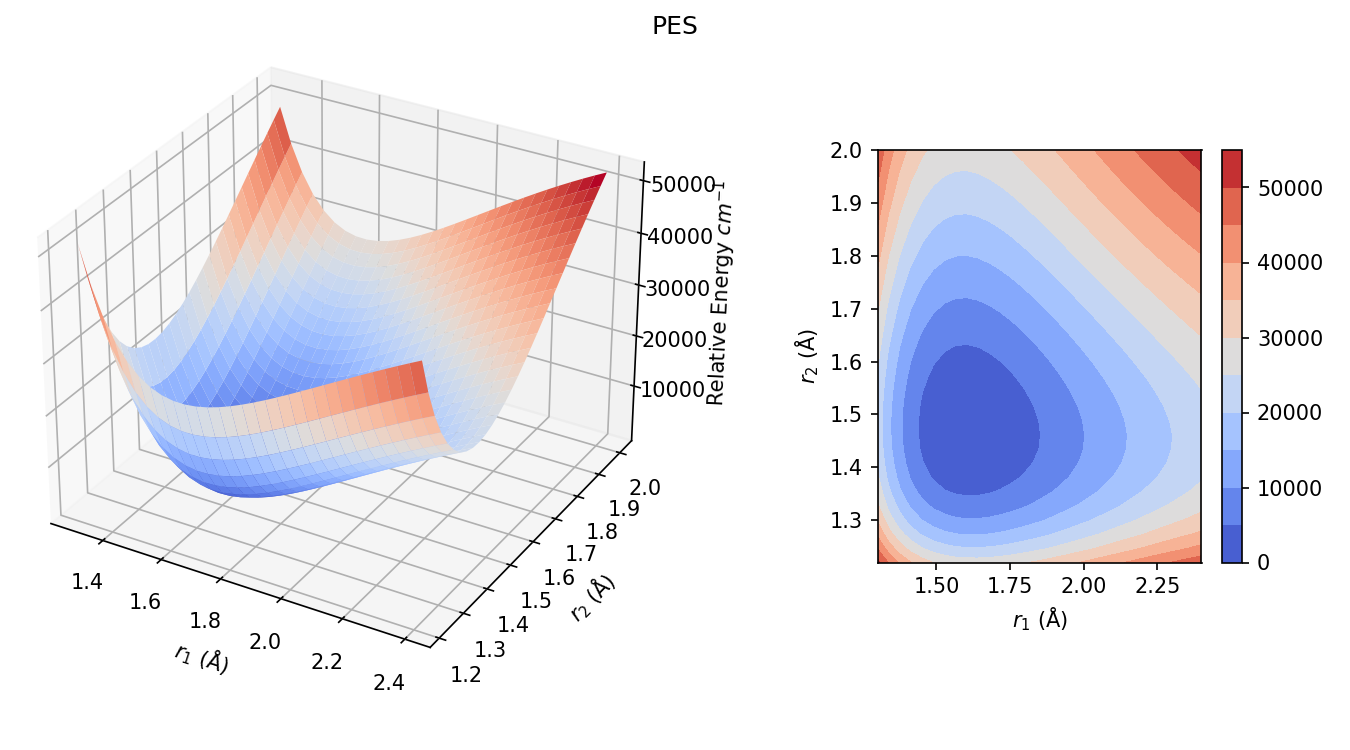

In [8]:
fig = plt.figure(figsize=(9, 5))
fig.suptitle('PES')
ax_3d = fig.add_axes([-0.1, 0.08, 0.7, 0.9], projection='3d')
#ax_3d = fig.add_subplot(1, 2, 1, projection='3d')
ax_3d.plot_surface(
    r1_mesh, r2_mesh, pes_vals_r1_r2,
    cmap=cm.coolwarm,
    shade=True,           # adds lighting effect
)
#ax_3d.set_box_aspect([1,1,0.6]) 
ax_3d.set_xlabel(r'$r_1$ (Å)')
ax_3d.set_ylabel(r'$r_2$ (Å)') 
ax_3d.set_zlabel(r'Relative Energy $cm^{-1}$');
ax_3d.axis('tight');

#ax_contour = fig.add_subplot(1, 2, 2, projection=None)
ax_contour = fig.add_axes([0.65, 0.25, 0.3, 0.55])  
contour = ax_contour.contourf(
    r1_mesh, r2_mesh, pes_vals_r1_r2,
    levels=10,
    cmap=cm.coolwarm
)
ax_contour.set_xlabel(r'$r_1$ (Å)')
ax_contour.set_ylabel(r'$r_2$ (Å)') 

plt.colorbar(contour, ax=ax_contour)
plt.show()

def pes_fitted_cis(input_geometry):
    input_geometry = np.append(input_geometry, 0)  
    geometry = np.array([input_geometry])
    return pes(geometry)

def pes_fitted_trans(input_geometry):
    input_geometry = np.append(input_geometry, 180)  
    geometry = np.array([input_geometry])
    return pes(geometry)

#guess = np.array([1.60346169, 1.46783211, 0.96779675, 110.73674459, 113.09775988])
guess = np.array([1.61099546, 1.46461729, 0.96380778, 110.46377558, 115.67092131])
cis_minima = minimize(pes_fitted_cis, 
                  guess, 
                  method='Nelder-Mead',
                  options={"disp": True})

print('Cis Minimum:')
print(cis_minima.x)
print()

trans_minima = minimize(pes_fitted_trans, 
                  guess, 
                  method='Nelder-Mead',
                  options={"disp": True})

print('Trans Minimum:')
print(trans_minima.x)

Optimization terminated successfully.
         Current function value: -0.047042
         Iterations: 134
         Function evaluations: 233
Cis Minimum:
[  1.60349702   1.46783637   0.9677846  110.72564807 113.06852946]

Optimization terminated successfully.
         Current function value: 987.292942
         Iterations: 135
         Function evaluations: 236
Trans Minimum:
[  1.61122052   1.46136709   0.9642619  108.49300319 111.95916102]

### MOLPRO Geo-Opt Values 
Cis:
- RPO1 =     1.46783211 ANGSTROM
- RPO2 =     1.60346169 ANGSTROM
- ROH =      0.96779675 ANGSTROM
- AOPO =     110.73674459 DEGREE
- APOH =     113.09775988 DEGREE

Trans
- RPO1 =      1.46139137 ANGSTROM
- RPO2 =      1.61121970 ANGSTROM
- ROH =       0.96427833 ANGSTROM
- AOPO =      108.50114827 DEGREE
- APOH =      111.98076633 DEGREE

#equil = np.array([1.61099546, 1.46461729, 0.96380778, 110.46377558, 115.67092131, 0])
#equil = np.array([1.60349679, 1.46783622, 0.96778457, 110.7256845, 113.06862761,0])
equil = [1.60346169, 1.46783211, 0.96779675, 110.73674459, 113.09775988, 0]

#1.60347504   1.46751864   0.96779105 110.72546394 113.06858429 0 converged values

dq = np.array([0.000002, 0.000002, 0.000002, 0.002, 0.002, 0])
#equil =  np.array([1.299546, 1.5, 0.8380778, 120.46377558, 98.67092131, 0])

for i in range(1000):
    dE_j = []
    for j in range(5):
        diff = np.zeros(6)
        diff[j] = dq[j]
        finite_diffs =  np.array([equil + diff, equil - diff])
        compute_E = pes(finite_diffs)
        dE_j.append((compute_E[0] - compute_E[1])/dq[j])
    dE_j.append(0)
    equil = equil - dE_j*dq
    if i%10 == 0:
        print(f'{equil}')